# Is het verdamping?

In dit experiment is er een verwarmingselement in een met water gevulde maatbeker gestopt. Elke minuut is de temperatuur van het water gemeten. Deze metingen zijn opgeslagen in [tempmetingen.csv](tempmetingen.csv).

Verder is gegeven dat: 
$m_{maatbeker} = 820.8 \mathrm{gr}$  
$m_{maatbeker + water, start} = 1292.9 \mathrm{gr}$  
$m_{maatbeker + water, eind} = 1274.9 \mathrm{gr}$

Het moge duidelijk zijn dat er water is 'verdwenen'. Ook is de eindtemperatuur van het water niet gelijk aan een proces waarbij verdamping en eventuele warmteverliezen niet meegenomen worden. 

```{exercise}
Onderzoek het proces door:
1. De plot van de metingen te maken, inclusief een verwachte trendlijn voor de temperatuur van het water als al de toegevoerde warmte gaat zitten in het water.
2. Bepaal of de totale hoeveelheid toegevoegde energie correspondeert met de opwarming en verdamping van het water, geef daarbij de aannames die je doet.
3. Geef aanbevelingen voor een verbetering van het experiment om (nog) beter het thermodynamische proces te kunnen onderzoeken en beschrijven.
```

### opdracht 1
Voor opdracht 1 geldt als alle toegevoerde warmte in het water gaat zitten:

$Q = m\cdot c_v\cdot \Delta T $ geeft
$T(t)=T_0 +\frac{P\cdot t}{m\cdot c}$ , dit is een rechte lijn in de tijd.



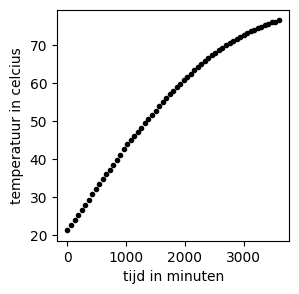

Vermogen is bepaald op 43.764517 W


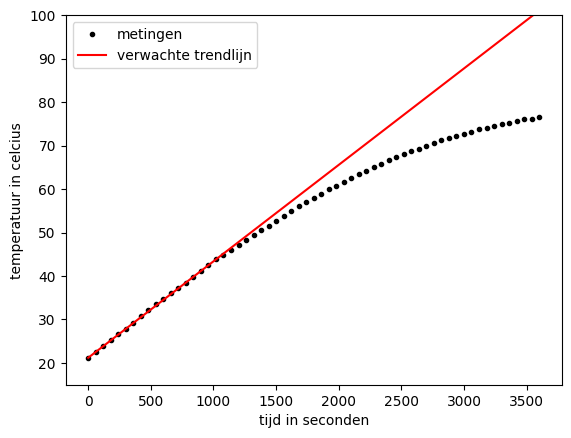

In [4]:
#libraries:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


###1
##importeren van de data
data=np.loadtxt("tempmetingen.csv", delimiter=";",skiprows=1)
data.shape
t_data=data[:,0]*60 #de tijd data in sec
T_data=data[:,1] #De temperatuur data in Celcius



##plotten van de data:
plt.figure(figsize=(3,3))
plt.plot(t_data,T_data,"k.",label="metingen")
plt.xlabel("tijd in minuten")
plt.ylabel("temperatuur in celcius")
plt.show()



##plotten van de verwachtte trend line als al de warmte in de het water gaat:
def T_func(t,P):
    ''''De verwachting is een rechte lijn, in het begin wordt een rechte lijn beschreven 
    door de data dus de verwachting is dat deze zich voort zou zetten als alle warmte in het water gaat. '''
    m_warm=1.2929-0.8208                   #de massa van de hoeveelehid water die verwarmd is, hierbij wordt de hoeveelheid massa die verdampt verwaarloosd
    c_w=4180                        #De soortelijke warmte van water in J/Kg/K
    return P*t/(m_warm*c_w) + 21.2  #bij t=0 is de temperatuur 21.2 
#fitten om beste lijn op te stellen:
val,cov=curve_fit(T_func,t_data[0:20],T_data[0:20]) #eerste 20 punten omdat hier nog een rechte lijn loopt
print("Vermogen is bepaald op %f W" %(val[0]))
#plot+data:
t_arr=np.linspace(min(t_data),max(t_data),100) #een array om de verwachting mee te plotten 
plt.figure()
plt.plot(t_data,T_data,"k.",label="metingen")
plt.plot(t_arr,T_func(t_arr,*val),"r-",label="verwachte trendlijn")
plt.xlabel("tijd in seconden")
plt.ylabel("temperatuur in celcius")
plt.ylim(15,100) #bij 100 graden warm het water niet meer op maar verdampt het
plt.legend()
plt.show()

### Opdracht 2
Voor opdracht 2 geld voor de verdamping van water:
$Q=m\cdot L_v$ met $Q$ de warmte energie, $m$ de massa en $L_v$,de latente warmte van verdamping, bij 100 graden geldt $L_v=2.26\cdot 10^6 J/kg$.

In [ ]:
#hoeveelheid warmte volgens theorie met verdamping:
m_verd=(1292.9-1274.9)*1e-3     #De massa van het water dat verdampt is in kg 
L_v=2.26e6                      #De verdampinswarmte van water in J/Kg
Q_verd=m_verd*L_v               #De enrgie verbruikt om deze hoeveelheid water te verdampen
m_warm=1.2929-0.8208            #de massa van de hoeveelehid water die verwarmd is, hierbij wordt de hoeveelheid massa die verdampt verwaarloosd
c_w=4180                        #De soortelijke warmte van water in J/Kg/K
Q_warm= c_w*m_warm*(max(T_data)-min(T_data)) #De warmte benodigt voor het opwarmen van het water.
Q_tot=Q_warm+Q_verd

#hoeveelheid warmte volgens het vermogen uit opdr 1:
P=val[0]        #het vermogen van het verwarmings element
t=60*60         #60 min in secpnden
Q_verm=P*t      #de totale energie die is geleverd gedurende tijd dat het verwamrings element aanstond
print("De hoeveelheid warmte die het verwarmingselement heeft geleverd is %.0f J, de hoeveelheid warmte die het water heeft opgenomen is %.0f J"%(Q_verm,Q_tot))
print("De totale hoeveelheid toegevoerde enregie correspondeerd dus redelijk met de hoeveelheid opgenomen energie,\
 het verschil wordt voornamelijk veroorzaakt doordat niet al het geleverde warmte in het water gaat zitten.")


De hoeveelheid warmte die het verwarmingselement heeft geleverd is 157552 J, de hoeveelheid warmte die het water heeft opgenomen is 150005 J
De totale hoeveelheid toegevoerde enregie correspondeerd dus redelijk met de hoeveelheid opgenomen energie, het verschil wordt voornamelijk veroorzaakt doordat niet al het geleverde warmte in het water gaat zitten.


### opdracht 3
Om beter dit process te kunnen onderzoeken is het handig om gebruik te maken van een calorimeter zodat warmteverlies naar de omgeving minimaal is en door gebruik te maken van gedistileerd water zodat het zeker is dat je alleen water bestudeerd. 